<a href="https://colab.research.google.com/github/akshay-aiml/LangChain_LangGraph/blob/main/Agentic_RAG_with_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q \
    langgraph \
    langchain \
    langchain-groq \
    langchain-community \
    langchain-huggingface \
    faiss-cpu \
    sentence-transformers \
    tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [4]:
from langchain_groq import ChatGroq
from google.colab import userdata

api_key1 = userdata.get("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=api_key1,
    temperature=0
)

In [5]:
# ── Standard library ──────────────────────────────────────────
from typing import List, Literal, TypedDict, Annotated
import operator

# ── LangGraph ─────────────────────────────────────────────────
from langgraph.graph import StateGraph, START, END

# ── LangChain core ────────────────────────────────────────────
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, AIMessage

# ── LLM: Groq ─────────────────────────────────────────────────
from langchain_groq import ChatGroq

# ── Embeddings: HuggingFace ────────────────────────────────────
from langchain_huggingface import HuggingFaceEmbeddings

# ── Vector Store: FAISS ────────────────────────────────────────
from langchain_community.vectorstores import FAISS

# ── Pydantic for structured output ────────────────────────────
from pydantic import BaseModel, Field

print("✅ All imports successful!")

✅ All imports successful!


In [6]:
from google.colab import userdata

api_key = userdata.get("HGF")

In [7]:
# ── HuggingFace Embeddings ─────────────────────────────────────
print("\n⏳ Loading HuggingFace embedding model (downloads on first run)...")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

print("✅ HuggingFace embeddings ready — model: all-MiniLM-L6-v2 (384-dim)")


⏳ Loading HuggingFace embedding model (downloads on first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ HuggingFace embeddings ready — model: all-MiniLM-L6-v2 (384-dim)


In [8]:
# Load Documents & Build FAISS Vector Store

# ── Sample Documents — replace with your own! ─────────────────
raw_texts = [
    """
    Groq is an AI infrastructure company that builds LPU (Language Processing Unit) chips
    specifically designed for AI inference. Their hardware allows extremely fast token generation,
    often 10x faster than traditional GPU-based inference. Groq's API provides access to
    open-source models like LLaMA 3, Mixtral, and Gemma at very high speeds.
    The Groq cloud service offers a free tier with generous rate limits.
    """,
    """
    RAG stands for Retrieval-Augmented Generation. It is a technique that combines
    information retrieval with language model generation. Instead of relying solely on
    the LLM's parametric knowledge, RAG first retrieves relevant documents from a
    knowledge base using semantic search, then passes those documents as context to the
    LLM to generate a grounded, accurate answer. RAG reduces hallucinations.
    """,
    """
    LangGraph is a library by LangChain for building stateful, multi-actor applications
    with LLMs. It models agent workflows as graphs where nodes are functions and edges
    are transitions (including conditional branches). LangGraph provides a StateGraph
    class that maintains state across node executions, making it ideal for complex
    agentic pipelines like RAG with reflection, multi-step reasoning, and tool use.
    """,
    """
    HuggingFace is an AI company and open-source platform that hosts thousands of
    pre-trained machine learning models, datasets, and spaces. The sentence-transformers
    library provides models trained to generate meaningful sentence embeddings.
    The model all-MiniLM-L6-v2 maps sentences to a 384-dimensional dense vector space
    and is widely used for semantic similarity and retrieval tasks.
    """,
    """
    FAISS (Facebook AI Similarity Search) is an open-source library by Meta AI
    for efficient similarity search and clustering of dense vectors. It is highly optimized
    for speed and supports both CPU and GPU operations. In RAG pipelines, FAISS acts as
    the vector database — storing document embeddings and enabling fast nearest-neighbor
    search to find the most relevant chunks for a given query embedding.
    """,
    """
    Agentic AI refers to AI systems that can autonomously plan, decide, and take actions.
    In agentic RAG with LangGraph, the pipeline uses a graph with conditional edges:
    the agent first grades the query to decide retrieval vs direct answer, then grades
    retrieved documents for relevance, and optionally rewrites the query if documents
    are not relevant before retrying retrieval. This self-correcting loop improves accuracy.
    """
]

documents = [Document(page_content=t.strip(), metadata={"source": f"doc_{i}"})
             for i, t in enumerate(raw_texts)]

# ── Chunk documents ────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
chunks = splitter.split_documents(documents)
print(f"✅ {len(documents)} documents → {len(chunks)} chunks")

# ── Build FAISS vector store ───────────────────────────────────
print("\n⏳ Building FAISS index...")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print(f"✅ FAISS index ready — {vectorstore.index.ntotal} vectors stored")

✅ 6 documents → 12 chunks

⏳ Building FAISS index...
✅ FAISS index ready — 12 vectors stored


In [9]:
# define StateGraph
class GraphState(TypedDict):
    """
    Shared state that flows through all LangGraph nodes.

    Attributes:
        question      : The original user question
        rewritten     : Reformulated question (if query rewriting happened)
        documents     : Retrieved documents from FAISS
        generation    : Final LLM answer
        route         : 'retrieve' or 'generate' (set by grade_query)
        doc_grade     : 'relevant' or 'not_relevant' (set by grade_docs)
        retry_count   : How many times query was rewritten (prevents infinite loops)
    """
    question   : str
    rewritten  : str
    documents  : List[Document]
    generation : str
    route      : str
    doc_grade  : str
    retry_count: int


In [10]:
# define Structure Output Schemas

# Schema for routing decision
class RouteQuery(BaseModel):
    """Agent's decision on whether to retrieve or answer directly."""
    route: Literal["retrieve", "generate"] = Field(
        description="'retrieve' if query needs knowledge base, 'generate' if answerable directly"
    )

# Schema for document grading
class GradeDocument(BaseModel):
    """Binary score for document relevance."""
    score: Literal["relevant", "not_relevant"] = Field(
        description="'relevant' if document addresses the question, else 'not_relevant'"
    )

# Bind structured outputs to LLM
router_llm = llm.with_structured_output(RouteQuery)
grader_llm = llm.with_structured_output(GradeDocument)

In [11]:
# define GraphNode



# NODE 1: grade_query
# Agent decides: retrieve from knowledge base OR answer directly

def grade_query(state: GraphState) -> dict:
    """
    Route the question to retrieval or direct generation.
    Uses structured output so we always get 'retrieve' or 'generate'.
    """
    print("\n🕵️  [Node: grade_query] Deciding route...")
    question = state["question"]

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
You are an expert router for a RAG system. The knowledge base contains information about:
- Groq (LPU chips, Groq API, model inference speed)
- RAG (Retrieval-Augmented Generation technique)
- LangGraph (stateful agent graphs, StateGraph, nodes, edges)
- HuggingFace (embeddings, sentence-transformers, all-MiniLM-L6-v2)
- FAISS (vector store, similarity search)
- Agentic AI systems

Decide:
- 'retrieve' → question is about the above topics and needs grounded facts
- 'generate' → question is generic/conversational/mathematical (no retrieval needed)
"""),
        ("human", "{question}")
    ])

    chain  = prompt | router_llm
    result = chain.invoke({"question": question})
    print(f"   → Route decided: '{result.route}'")
    return {"route": result.route, "retry_count": state.get("retry_count", 0)}



In [12]:

# NODE 2: retrieve
# Fetch top-k relevant chunks from FAISS

def retrieve(state: GraphState) -> dict:
    """
    Run FAISS similarity search using the current question
    (or rewritten question if query rewriting happened).
    """
    print("\n📚 [Node: retrieve] Searching FAISS vector store...")

    # Use rewritten query if available, else original
    query = state.get("rewritten") or state["question"]
    docs  = retriever.invoke(query)

    print(f"   → Retrieved {len(docs)} chunks")
    for i, d in enumerate(docs):
        print(f"   [{i+1}] {d.page_content[:80]}...")
    return {"documents": docs}

In [13]:

# NODE 3: grade_docs
# Check if retrieved docs are actually relevant to the question

def grade_docs(state: GraphState) -> dict:
    """
    Grade each retrieved document for relevance.
    If ANY doc is relevant → proceed to generate.
    If NONE are relevant → rewrite query.
    """
    print("\n🔬 [Node: grade_docs] Grading document relevance...")
    question  = state["question"]
    documents = state["documents"]

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
You are a relevance grader. Given a question and a retrieved document,
determine if the document contains information relevant to answering the question.
Be lenient — partial relevance counts as 'relevant'.
Respond with 'relevant' or 'not_relevant'.
"""),
        ("human", "Question: {question}\n\nDocument: {document}")
    ])

    chain = prompt | grader_llm
    grades = []

    for doc in documents:
        result = chain.invoke({"question": question, "document": doc.page_content})
        grades.append(result.score)
        print(f"   → Doc grade: {result.score} | '{doc.page_content[:60]}...'")

    # If at least one doc is relevant → proceed
    final_grade = "relevant" if "relevant" in grades else "not_relevant"
    print(f"   → Overall grade: {final_grade}")
    return {"doc_grade": final_grade}

In [14]:


# NODE 4: rewrite_query
# Reformulate the question to improve retrieval results

def rewrite_query(state: GraphState) -> dict:
    """
    Rewrite the user's question to be more search-friendly.
    Called when retrieved docs are not relevant.
    """
    print("\n✏️  [Node: rewrite_query] Reformulating query...")
    question    = state["question"]
    retry_count = state.get("retry_count", 0)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
You are a query rewriter for RAG systems. The original query did not retrieve relevant documents.
Rewrite the query to be more specific and semantically precise for vector search.
Return ONLY the rewritten query, nothing else.
"""),
        ("human", "Original query: {question}")
    ])

    chain      = prompt | llm | StrOutputParser()
    rewritten  = chain.invoke({"question": question})
    print(f"   → Original : {question}")
    print(f"   → Rewritten: {rewritten}")
    return {"rewritten": rewritten, "retry_count": retry_count + 1}

In [15]:

# NODE 5: generate
# Generate the final answer (RAG-grounded or direct)

def generate(state: GraphState) -> dict:
    """
    Generate the final answer.
    - If documents are present → RAG-grounded answer
    - If no documents → direct LLM answer
    """
    print("\n🤖 [Node: generate] Generating answer...")
    question  = state["question"]
    documents = state.get("documents", [])

    if documents:
        # RAG prompt: ground answer in retrieved context
        context = "\n\n".join([d.page_content for d in documents])
        prompt  = ChatPromptTemplate.from_messages([
            ("system", """
You are a helpful assistant. Answer the question using ONLY the provided context.
Be concise and accurate. If the context doesn't fully answer the question, say so.

Context:
{context}
"""),
            ("human", "{question}")
        ])
        chain      = prompt | llm | StrOutputParser()
        generation = chain.invoke({"context": context, "question": question})
        print("   → Mode: RAG (grounded on retrieved documents)")
    else:
        # Direct generation — no retrieval
        prompt  = ChatPromptTemplate.from_messages([
            ("system", "You are a helpful AI assistant. Answer concisely."),
            ("human", "{question}")
        ])
        chain      = prompt | llm | StrOutputParser()
        generation = chain.invoke({"question": question})
        print("   → Mode: Direct (no retrieval)")

    return {"generation": generation}

In [16]:
# Define Conditional Edges

MAX_RETRIES = 2   # Max query rewrites before forcing generation


def route_after_grade_query(state: GraphState) -> str:
    """After grade_query: go to 'retrieve' or 'generate' node."""
    return state["route"]   # 'retrieve' or 'generate'


def route_after_grade_docs(state: GraphState) -> str:
    """
    After grade_docs:
    - 'relevant'     → go to generate
    - 'not_relevant' → rewrite query (unless max retries exceeded)
    """
    grade       = state["doc_grade"]
    retry_count = state.get("retry_count", 0)

    if grade == "relevant":
        return "generate"
    elif retry_count >= MAX_RETRIES:
        print(f"   ⚠️  Max retries ({MAX_RETRIES}) reached — forcing generation with available docs")
        return "generate"
    else:
        return "rewrite_query"



In [17]:
# Build LanGraph StateGraph

# ── Initialize graph
graph_builder = StateGraph(GraphState)

# ── Add nodes
graph_builder.add_node("grade_query",   grade_query)
graph_builder.add_node("retrieve",      retrieve)
graph_builder.add_node("grade_docs",    grade_docs)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("generate",      generate)

# ── Add edges

# START → grade_query (always first)
graph_builder.add_edge(START, "grade_query")

# grade_query → retrieve OR generate (conditional)
graph_builder.add_conditional_edges(
    "grade_query",
    route_after_grade_query,
    {
        "retrieve": "retrieve",
        "generate": "generate",
    }
)

# retrieve → grade_docs (always)
graph_builder.add_edge("retrieve", "grade_docs")

# grade_docs → generate OR rewrite_query (conditional)
graph_builder.add_conditional_edges(
    "grade_docs",
    route_after_grade_docs,
    {
        "generate":      "generate",
        "rewrite_query": "rewrite_query",
    }
)

# rewrite_query → retrieve (loop back to retry)
graph_builder.add_edge("rewrite_query", "retrieve")

# generate → END (always)
graph_builder.add_edge("generate", END)



In [18]:
# ── Compile
graph = graph_builder.compile()

print("✅ LangGraph compiled successfully!")
print("\nGraph nodes:", list(graph.nodes.keys()))

✅ LangGraph compiled successfully!

Graph nodes: ['__start__', 'grade_query', 'retrieve', 'grade_docs', 'rewrite_query', 'generate']


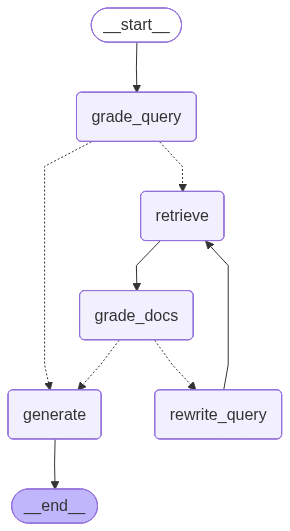

In [19]:
# Visualize the graph as a Mermaid diagram
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print mermaid text
    print("Graph visualization:")
    print(graph.get_graph().draw_mermaid())

In [20]:
# Run the Agentic Graph

def run_rag(question: str) -> str:
    """
    Run the full LangGraph agentic RAG pipeline for a given question.
    Returns the final generated answer.
    """
    print(f"\n{'═'*65}")
    print(f"❓ QUESTION: {question}")
    print(f"{'═'*65}")

    # Initial state
    initial_state: GraphState = {
        "question":    question,
        "rewritten":   "",
        "documents":   [],
        "generation":  "",
        "route":       "",
        "doc_grade":   "",
        "retry_count": 0,
    }

    # Run graph
    final_state = graph.invoke(initial_state)

    answer = final_state["generation"]
    print(f"\n{'─'*65}")
    print(f"✅ FINAL ANSWER:\n{answer}")
    print(f"{'─'*65}")
    return answer



In [21]:
# ✅ Should trigger RETRIEVE path (knowledge base topic)
_ = run_rag("What is LangGraph and how does it help build agentic pipelines?")


═════════════════════════════════════════════════════════════════
❓ QUESTION: What is LangGraph and how does it help build agentic pipelines?
═════════════════════════════════════════════════════════════════

🕵️  [Node: grade_query] Deciding route...
   → Route decided: 'retrieve'

📚 [Node: retrieve] Searching FAISS vector store...
   → Retrieved 3 chunks
   [1] LangGraph is a library by LangChain for building stateful, multi-actor applicati...
   [2] Agentic AI refers to AI systems that can autonomously plan, decide, and take act...
   [3] class that maintains state across node executions, making it ideal for complex
 ...

🔬 [Node: grade_docs] Grading document relevance...
   → Doc grade: relevant | 'LangGraph is a library by LangChain for building stateful, m...'
   → Doc grade: relevant | 'Agentic AI refers to AI systems that can autonomously plan, ...'
   → Doc grade: relevant | 'class that maintains state across node executions, making it...'
   → Overall grade: relevant

🤖 [Node

In [22]:
_ = run_rag("How does Groq's LPU chip make inference faster than GPUs?")



═════════════════════════════════════════════════════════════════
❓ QUESTION: How does Groq's LPU chip make inference faster than GPUs?
═════════════════════════════════════════════════════════════════

🕵️  [Node: grade_query] Deciding route...
   → Route decided: 'retrieve'

📚 [Node: retrieve] Searching FAISS vector store...
   → Retrieved 3 chunks
   [1] Groq is an AI infrastructure company that builds LPU (Language Processing Unit) ...
   [2] open-source models like LLaMA 3, Mixtral, and Gemma at very high speeds.
    The...
   [3] Agentic AI refers to AI systems that can autonomously plan, decide, and take act...

🔬 [Node: grade_docs] Grading document relevance...
   → Doc grade: relevant | 'Groq is an AI infrastructure company that builds LPU (Langua...'
   → Doc grade: not_relevant | 'open-source models like LLaMA 3, Mixtral, and Gemma at very ...'
   → Doc grade: not_relevant | 'Agentic AI refers to AI systems that can autonomously plan, ...'
   → Overall grade: relevant

🤖 [No

In [23]:
# ✅ Should trigger RETRIEVE path
_ = run_rag("What is FAISS and why is it used in RAG systems?")


═════════════════════════════════════════════════════════════════
❓ QUESTION: What is FAISS and why is it used in RAG systems?
═════════════════════════════════════════════════════════════════

🕵️  [Node: grade_query] Deciding route...
   → Route decided: 'retrieve'

📚 [Node: retrieve] Searching FAISS vector store...
   → Retrieved 3 chunks
   [1] RAG stands for Retrieval-Augmented Generation. It is a technique that combines
 ...
   [2] FAISS (Facebook AI Similarity Search) is an open-source library by Meta AI
    f...
   [3] knowledge base using semantic search, then passes those documents as context to ...

🔬 [Node: grade_docs] Grading document relevance...
   → Doc grade: not_relevant | 'RAG stands for Retrieval-Augmented Generation. It is a techn...'
   → Doc grade: relevant | 'FAISS (Facebook AI Similarity Search) is an open-source libr...'
   → Doc grade: not_relevant | 'knowledge base using semantic search, then passes those docu...'
   → Overall grade: relevant

🤖 [Node: gener

In [24]:
# Should be answered DIRECTLY (simple math)
_ = run_rag("What is the square root of 144?")


═════════════════════════════════════════════════════════════════
❓ QUESTION: What is the square root of 144?
═════════════════════════════════════════════════════════════════

🕵️  [Node: grade_query] Deciding route...
   → Route decided: 'generate'

🤖 [Node: generate] Generating answer...
   → Mode: Direct (no retrieval)

─────────────────────────────────────────────────────────────────
✅ FINAL ANSWER:
The square root of 144 is 12.
─────────────────────────────────────────────────────────────────
